In [ ]:
# python3 -m pip install matplotlib 
# https://code.visualstudio.com/docs/python/python-tutorial

import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

# Heuristisches Verfahren

## 1) Maze Solver

1) Schritt: Installieren der Bibliotheken
- installiere die Bibliotheken:
    - numpy as np
    - matplotlib.pyplot as plt
    - heapq

2) Schritt: Implementieren der Heuristik-Funktion (manhattan_dist)
- Da wir uns in einem Gitter bewegen und nur nach oben, unten, links oder rechts gehen können, nutzen wir die Manhattan-Distanz. Diese berechnet die Summe der absoluten Differenzen der Koordinaten.
- Schreibe eine Funktion, die zwei Punkte (x1, y1) und (x2, y2) entgegennimmt und den Manhattan-Abstand berechnet. 
- **Tipp verwende abs**

3) Schritt: Initialisierung der Datenstrukturen
- Bevor die Suche beginnt, müssen wichtige Strukturen innerhalb von a_star vorbereitet werden:
    - erstelle ein 2D-Gitter, welches mit shape ein Tupel zurück gibt,``maze.shape``
        - Den ersten Wert für die Anzahl der Zeilen (Y-Achse).
        - Den zweiten Wert für die Anzahl der Spalten (X-Achse).
    - Open List (Priority Queue): Hier werden Knoten gespeichert im Tupel (Kosten, Position), die als Nächstes besucht werden könnten. 
        - Erstelle eine leere Liste zum speichen der Knoten mit dem Namen ``open_list``
        - Nutze heapq, damit der Knoten mit dem kleinsten f(n) immer oben liegt.
            - Nutze von heapq die Funktion heappush und gebe ihr die open_list, 0 und start Wert mit
    - erstelle einen leeren Pfad-Speicher als Dictionary, um den Weg rückwärts zu rekonstruieren mit dem Namen ``came_from``
        - Das Dictionary enthält den aktuellen Knoten, Value: Vorgänger-Knoten.
    - Erstelle ein Dictionary ``g_score``, das für jeden besuchten Knoten die bisher geringsten Kosten vom Start speichert (Initialisierung des Starts mit 0, alle anderen unendlich).
        -  initialisiere alle Werte mit Unendlich, außer dem Startpunkt (0). Dieser ist gleich {start: 0}
    - Errechne in ``f_score`` die geschätzten Gesamtkosten (g + h) mit der Funktion ``manhattan_dist``, welcher die Suche in Richtung Ziel lenkt.
    - kopiere die folgende Codezeile: ``visited = np.zeros_like(maze, dtype=bool)``, welche eine Matrix zur Visualisierung: Speichert, welche Felder der Algorithmus 'berührt' hat.
    ``
4) Schritt: implementiere die while-Hauptschleife (Searching)
- Solange die open_list nicht leer ist:
    - Entnehme den Knoten mit dem kleinsten f(n) (heapq.heappop).
    - Extrahiere den Knoten mit dem aktuell niedrigsten geschätzten f_score. Das ist die 'Heuristische Entscheidung': Wir gehen dort lang, wo es am günstigsten aussieht.
        - Nehme den Code: 
                    ``current = heapq.heappop(open_list)[1]``
                    ``visited[current] = True``
    - Prüfe: Ist dieser Knoten das Ziel? Wenn ja, beenden Sie die Suche.
        - es soll dann zurück gegeben werden die Funktion reconstruct_path und die Variabeln came_from und current sowie visited
    - Untersuche die Nachbarn (oben, unten, links, rechts):
        - Die Richtungs-Liste ist [(0, 1), (0, -1), (1, 0), (-1, 0)] und prüft immer von dem bestehenden aktuellen Punkt aus
            - nutze dx und dy um die Änderungen in der Vertikalen und Horizontalen anzuzeigen
        - Validierung: Liegt der Nachbar innerhalb des Spielfelds?
        - Ignorieren Sie Wände (1) und Felder außerhalb des Spielfelds.
            - ``maze[neighbor] == 1``
        - Gebe den vorläufigern ``g_score`` als ``tentative_g_score`` wieder. Berechnen Sie einen vorläufigen g_score (Kosten des Vaters + 1).Also die Kosten vom Start zum aktuellen Feld + 1 (Schritt zum Nachbarn).
        - Falls dieser Weg zum Nachbarn besser (günstiger, kürzer) ist als der bisher bekannte
            - prüfe ob  der Nachbar noch nicht im g_score ist **oder** ist der neue Weg über das aktuelle Feld kürzer als der alte Weg
            - Wenn das so ist:
                - Speichere den Weg in ``came_from``
                - aktualisiere ``g_score`` und 
                - berechne den neuen ``f_score``.
            - Füge den Nachbarn der open_list hinzu.
                - ``heapq.heappush(open_list, (f_score[neighbor], neighbor))``
    - gebe None und visited zurück

5) Schritt: Den Pfad rekonstruieren (reconstruct_path)
- Wenn das Ziel gefunden wurde, müssen wir die "Brotkrumen" in came_from zurückverfolgen.
    - Beginne beim Zielknoten und folge den Pointern rückwärts bis zum Start. 
    - Gebe diese Liste in der richtigen Reihenfolge (Start bis Ziel) zurück.

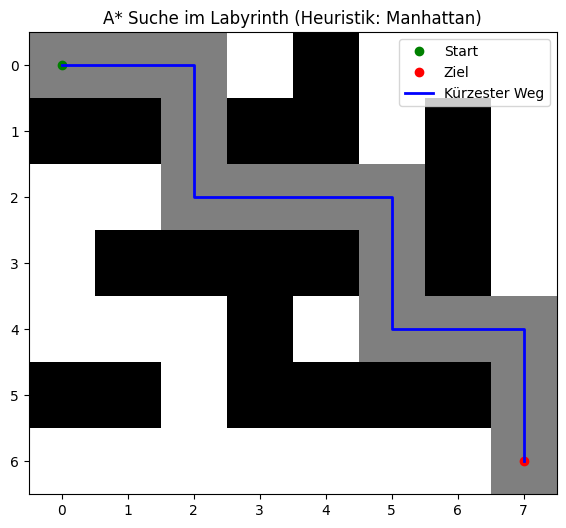

In [2]:
# Labyrinth Setup (0=Pfad, 1=Wand)
maze = np.array([
    [0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0]
])

start, goal = (0, 0), (6, 7)
pfad, besucht = a_star(maze, start, goal)

# Visualisierung aufbereiten
display_maze = np.copy(maze).astype(float)
for r, c in pfad:
    display_maze[r, c] = 0.5 # Markierung für den gefundenen Pfad

plt.figure(figsize=(8, 6))
plt.imshow(display_maze, cmap='binary')
plt.plot(start[1], start[0], 'go', label='Start') # Grün
plt.plot(goal[1], goal[0], 'ro', label='Ziel')   # Rot

# Pfad als Linie zeichnen
py, px = zip(*pfad)
plt.plot(px, py, color='blue', linewidth=2, label='Kürzester Weg')

plt.title("A* Suche im Labyrinth (Heuristik: Manhattan)")
plt.legend()
plt.show()

## 2) Benutzung Templates und Experimentieren mit verschiedeneen Heuristiken

In [3]:
# Labyrinth Setup (0=Pfad, 1=Wand)
import numpy as np

# 0 = Frei begehbar, 1 = Wand
maze = np.array([
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
])

# Neue Start- und Zielkoordinaten für dieses Gitter
start = (0, 0)
goal = (13, 13)
pfad, besucht = a_star(maze, start, goal)

# Visualisierung aufbereiten
display_maze = np.copy(maze).astype(float)
for r, c in pfad:
    display_maze[r, c] = 0.5 # Markierung für den gefundenen Pfad

plt.figure(figsize=(8, 6))
plt.imshow(display_maze, cmap='binary')
plt.plot(start[1], start[0], 'go', label='Start') # Grün
plt.plot(goal[1], goal[0], 'ro', label='Ziel')   # Rot

# Pfad als Linie zeichnen
py, px = zip(*pfad)
plt.plot(px, py, color='blue', linewidth=2, label='Kürzester Weg')

plt.title("A* Suche im Labyrinth (Heuristik: Manhattan)")
plt.legend()
plt.show()

TypeError: 'NoneType' object is not iterable

In [ ]:
# Fehler liegt in der Wand

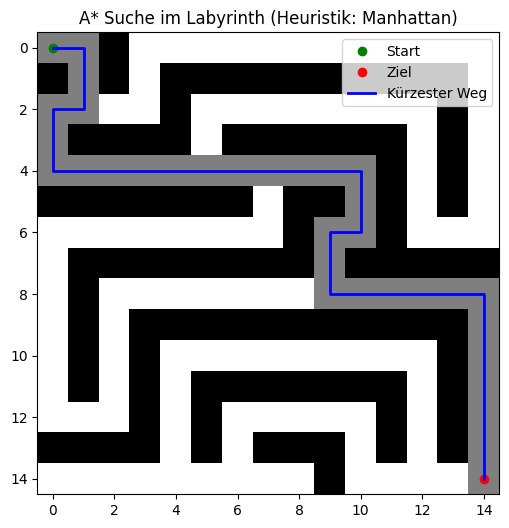

In [ ]:
# Labyrinth Setup (0=Pfad, 1=Wand)
import numpy as np

# 0 = Frei begehbar, 1 = Wand
maze = np.array([
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
])

# Neue Start- und Zielkoordinaten für dieses Gitter
start = (0, 0)
goal = (14, 14)
pfad, besucht = a_star(maze, start, goal)

# Visualisierung aufbereiten
display_maze = np.copy(maze).astype(float)
for r, c in pfad:
    display_maze[r, c] = 0.5 # Markierung für den gefundenen Pfad

plt.figure(figsize=(8, 6))
plt.imshow(display_maze, cmap='binary')
plt.plot(start[1], start[0], 'go', label='Start') # Grün
plt.plot(goal[1], goal[0], 'ro', label='Ziel')   # Rot

# Pfad als Linie zeichnen
py, px = zip(*pfad)
plt.plot(px, py, color='blue', linewidth=2, label='Kürzester Weg')

plt.title("A* Suche im Labyrinth (Heuristik: Manhattan)")
plt.legend()
plt.show()